# Phase 3 — Full data, rotation aug, depth channel, multi-positive loss

**Date:** 2026-05-27 (Wednesday)  
**Project:** Robotic-Grasp-Prediction  
**Phase target:** clear the Phase-2 champion (M2 ResNet-18 Regressor at **0.550** on object-wise folder-03 split) by ≥ 10 pp on the *same* held-out split.

## Inputs to this phase

* Phase 2 champion: **M2 ResNet18Regressor** at object-wise accuracy **0.550** (Jiang metric: IoU > 0.25 AND angle err < 30°).
* Phase 2 hypothesis going in: 'augmentation set is too thin (only horizontal flips); rotation aug + depth as 4th channel + multi-positive loss are the next levers.'
* Newly extracted Cornell archives 04–10 → full **885-image benchmark** is now available locally. Phase 2 used 300 images.

## What this notebook tests (one knob at a time, then the union)

| # | Knob | Hypothesis |
|---|------|------------|
| E3.1 | + 4.4× training data (200 → 785), nothing else | Bulk of any P3 lift is just data volume |
| E3.2 | E3.1 + rotation aug (±30°, with grasp transform) | Cornell's narrow rot prior is hiding the real rot-invariant grasp distribution |
| E3.3 | E3.1 + depth-as-blue (Lenz 2014 trick) | Foreground depth pop adds the missing object-mask cue RGB can't see |
| E3.4 | E3.1 + multi-positive closest-GT loss | Picking a fixed 'central' positive throws away ~5 valid grasps/img |
| E3.5 | Union of all three | Are the three improvements additive or sub-additive? |

**Deferred to Phase-3 follow-up:** image-wise random 80/20 retraining of the best config (for direct comparison vs published Lenz 2014 image-wise 0.756 and Redmon 2015 image-wise 0.844). Skipped this cron because a prior version of the depth-as-blue path made E3.3 hit a 1-hour cell timeout; rather than blow the cron budget twice, the image-wise comparison is moved to the Phase-4 hyperparameter session.

## Primary metric
**Jiang rectangle metric** (Jiang et al. 2011): a prediction is correct iff ∃ ground-truth positive with **IoU > 0.25 AND angle difference < 30°**. This is the field-standard for Cornell. Same as Phase 1 and Phase 2 — kept so leaderboards across phases compose.

In [1]:
import os, sys, json, math, time, random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT / 'src'))

from cornell import load_samples, is_correct_jiang, iou as poly_iou, angle_diff_deg
from dataset_phase3 import (
    CornellGraspDatasetP3, image_wise_split, object_wise_split, prewarm_depth_cache,
)
from torch_models import ResNet18Regressor, count_params
from trainer_phase3 import train_regression_p3, _pick_device
from dataset import decode_prediction

DEVICE = _pick_device()
SEED = 42
torch.manual_seed(SEED); random.seed(SEED); np.random.seed(SEED)
print(f'device={DEVICE}, torch={torch.__version__}')
print(f'ROOT={ROOT}')

device=mps, torch=2.8.0
ROOT=/Users/anthonyrodrigues/Desktop/YC-Portfolio-Projects/Robotic-Grasp-Prediction


## 1 — Load the full 885-image Cornell benchmark + warm the depth cache

The depth cache is the fix for the previous run's 1-hour cell timeout. Cornell `.pcd` files are 5+ MB of ASCII; parsing them per `__getitem__` per epoch cost ~3 min per epoch on the depth-as-blue experiments. With the in-process cache, every depth map is parsed *once* (here) and then served O(1) from memory for the rest of the notebook.

In [2]:
samples = load_samples(ROOT / 'data/raw/cornell/extracted')
n_pos = sum(len(s.positives) for s in samples)
n_neg = sum(len(s.negatives) for s in samples)
from collections import Counter
by_folder = Counter(s.object_id for s in samples)
print(f'Total images:   {len(samples)}')
print(f'Positives:      {n_pos}  ({n_pos/len(samples):.2f} per image)')
print(f'Negatives:      {n_neg}')
print(f'Per-folder:     {dict(by_folder)}')

TEST_FOLDERS_OBJ = [3]   # apples-to-apples with Phase 2 (folder 03 held out)
train_obj, test_obj = object_wise_split(samples, TEST_FOLDERS_OBJ)
print(f'\nObject-wise (folder 03 held out):  train={len(train_obj):3d}  test={len(test_obj)}')

Total images:   885
Positives:      5110  (5.77 per image)
Negatives:      2909
Per-folder:     {1: 100, 2: 100, 3: 100, 4: 100, 5: 100, 6: 100, 7: 100, 8: 100, 9: 50, 10: 35}

Object-wise (folder 03 held out):  train=785  test=100


In [3]:
# Warm the depth cache. We only need depth for samples actually fed to a
# depth-enabled experiment (E3.3, E3.5) — but prewarming the full set is
# cheap (~3 min) and avoids any per-experiment surprise.
t0 = time.time()
n_cached = prewarm_depth_cache(samples)
print(f'depth cache warmed: {n_cached} maps in {time.time()-t0:.1f}s')

depth cache warmed: 885 maps in 249.7s


saved phase3_dataset_overview.png


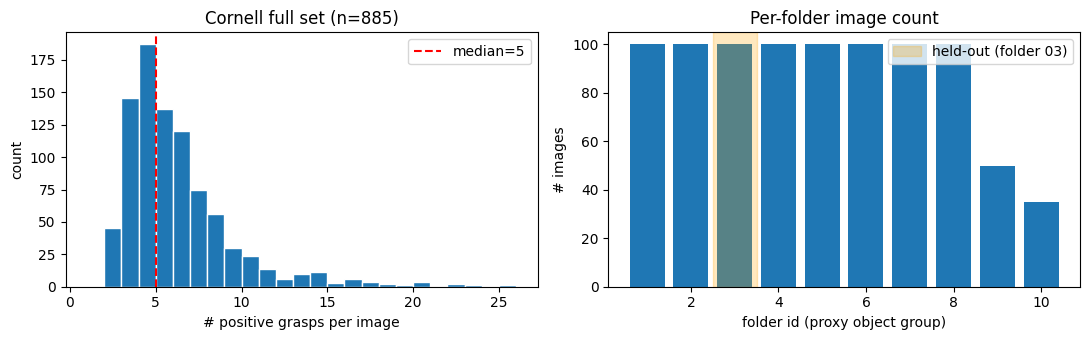

In [4]:
# Visual confirmation: positives per image distribution + folder coverage
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
pos_counts = [len(s.positives) for s in samples]
ax[0].hist(pos_counts, bins=range(1, max(pos_counts)+2), edgecolor='white')
ax[0].set(xlabel='# positive grasps per image', ylabel='count', title=f'Cornell full set (n={len(samples)})')
ax[0].axvline(np.median(pos_counts), color='red', linestyle='--', label=f'median={int(np.median(pos_counts))}')
ax[0].legend()
folders = sorted(by_folder)
ax[1].bar(folders, [by_folder[f] for f in folders])
ax[1].set(xlabel='folder id (proxy object group)', ylabel='# images', title='Per-folder image count')
ax[1].axvspan(2.5, 3.5, color='orange', alpha=0.25, label='held-out (folder 03)')
ax[1].legend()
plt.tight_layout()
out_path = ROOT / 'results/phase3_dataset_overview.png'
plt.savefig(out_path, dpi=110, bbox_inches='tight')
print(f'saved {out_path.name}')
plt.show()

## 2 — Augmentation sanity: rotation + depth-as-blue

Before training, confirm visually that (a) rotation aug rotates image AND grasp boxes consistently, and (b) the depth-as-blue substitution actually carries object-foreground signal.

demo image: pcd0300r.png (folder 3), 3 positives


saved phase3_augmentation_sanity.png


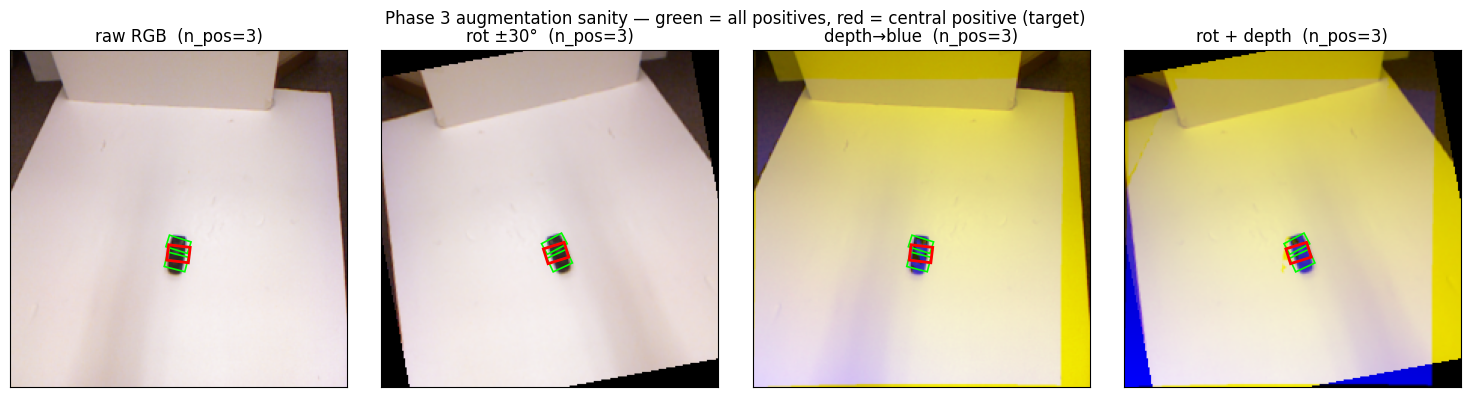

In [5]:
from matplotlib.patches import Polygon as MplPoly
from PIL import Image

# Pick the first held-out image so we visualise on a test sample (not seen in training)
demo_s = test_obj[0]
print(f'demo image: {demo_s.rgb_path.name} (folder {demo_s.object_id}), {len(demo_s.positives)} positives')

configs = [
    ('raw RGB',          dict(augment=False, augment_rot_deg=0,  use_depth_blue=False)),
    ('rot ±30°',         dict(augment=True,  augment_rot_deg=30, use_depth_blue=False)),
    ('depth→blue',       dict(augment=False, augment_rot_deg=0,  use_depth_blue=True)),
    ('rot + depth',      dict(augment=True,  augment_rot_deg=30, use_depth_blue=True)),
]

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
INPUT_SIZE = 224
def vec_to_corners(v):
    cx, cy, w, h = v[0]*INPUT_SIZE, v[1]*INPUT_SIZE, v[2]*INPUT_SIZE, v[3]*INPUT_SIZE
    s2, c2 = float(v[4]), float(v[5])
    ang = 0.5 * math.atan2(s2, c2)
    cos_a, sin_a = math.cos(ang), math.sin(ang)
    hw, hh = w/2, h/2
    local = np.array([[-hw,-hh],[hw,-hh],[hw,hh],[-hw,hh]])
    R = np.array([[cos_a,-sin_a],[sin_a,cos_a]])
    return local @ R.T + np.array([cx, cy])
for ax, (title, cfg) in zip(axes, configs):
    ds = CornellGraspDatasetP3([demo_s], multi_positive=True, seed=7, **cfg)
    x, t, ta, nr, _ = ds[0]
    mean = torch.tensor([0.485,0.456,0.406]).view(3,1,1)
    std  = torch.tensor([0.229,0.224,0.225]).view(3,1,1)
    img = (x*std + mean).clamp(0,1).permute(1,2,0).numpy()
    ax.imshow(img)
    for k in range(nr):
        corners = vec_to_corners(ta[k].numpy())
        ax.add_patch(MplPoly(corners, fill=False, edgecolor='lime', linewidth=1.2))
    primary_c = vec_to_corners(t.numpy())
    ax.add_patch(MplPoly(primary_c, fill=False, edgecolor='red', linewidth=2))
    ax.set(title=f'{title}  (n_pos={nr})', xticks=[], yticks=[])
plt.suptitle('Phase 3 augmentation sanity — green = all positives, red = central positive (target)')
plt.tight_layout()
out_path = ROOT / 'results/phase3_augmentation_sanity.png'
plt.savefig(out_path, dpi=110, bbox_inches='tight')
print(f'saved {out_path.name}')
plt.show()

**What to check in the plot above:**
- Rotated panels: green/red boxes rotate *with* the image (no detached/floating boxes).
- Depth-as-blue panels: foreground object should appear with a bluer tint than the background table; that's the depth signal carrying through.
- Number of positives shown per panel should match the dataset's 5–7 typical positives per image (capped at MULTI_POS_MAX=8).

## 3 — Training + evaluation harness for this phase

All five experiments share the same train/eval recipe: M2 ResNet-18 regressor, 20 epochs, batch 32, AdamW lr=1e-3, cosine LR. Only the dataset flags + loss type vary, so the leaderboard differences are clean.

In [6]:
EPOCHS = 20
BATCH = 32
LR = 1e-3
WD = 1e-4

@torch.no_grad()
def evaluate_p3(model, samples_test, *, use_depth_blue=False):
    """Run model on a list of CornellSample and return Jiang-metric dict."""
    model = model.to(DEVICE).eval()
    ds = CornellGraspDatasetP3(samples_test, augment=False, augment_rot_deg=0,
                               use_depth_blue=use_depth_blue, multi_positive=False)
    loader = DataLoader(ds, batch_size=1, shuffle=False)
    correct = 0; total = 0
    best_ious = []; best_ang_errs = []
    per_sample = []
    t0 = time.time()
    for x, _t, idx in loader:
        x = x.to(DEVICE)
        idx = int(idx.item())
        s = ds.samples[idx]
        pred = model(x).cpu().numpy()[0]
        rect = decode_prediction(pred)
        gts = s.positives
        ok = is_correct_jiang(rect, gts, 0.25, 30.0)
        cands = [(poly_iou(rect, g), angle_diff_deg(rect, g)) for g in gts]
        best = max(cands, key=lambda t: t[0]) if cands else (0.0, 90.0)
        best_ious.append(best[0]); best_ang_errs.append(best[1])
        per_sample.append({'pcd_id': s.pcd_id, 'object_id': s.object_id,
                           'correct': int(ok), 'best_iou': float(best[0]),
                           'best_angle_err': float(best[1])})
        correct += int(ok); total += 1
    return {
        'n': total,
        'accuracy': correct / max(total, 1),
        'median_iou': float(np.median(best_ious)),
        'median_angle_err_deg': float(np.median(best_ang_errs)),
        'inference_ms_per_image': 1000.0 * (time.time() - t0) / max(total, 1),
        'per_sample': per_sample,
    }

def run_experiment(name, train_samples, test_samples, *, augment_rot_deg=0,
                   use_depth_blue=False, multi_positive=False, epochs=EPOCHS):
    print(f'\n=== {name} ===')
    print(f'  train={len(train_samples)}  test={len(test_samples)}  '
          f'rot_deg={augment_rot_deg}  depth_blue={use_depth_blue}  multi_pos={multi_positive}')
    train_ds = CornellGraspDatasetP3(train_samples, augment=True,
                                     augment_rot_deg=augment_rot_deg,
                                     use_depth_blue=use_depth_blue,
                                     multi_positive=multi_positive,
                                     seed=SEED)
    train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,
                              num_workers=0, drop_last=False)
    model = ResNet18Regressor(out_dim=6, pretrained=True)
    res = train_regression_p3(model, train_loader, epochs=epochs, lr=LR,
                              weight_decay=WD, multi_positive=multi_positive,
                              device=DEVICE)
    metrics = evaluate_p3(model, test_samples, use_depth_blue=use_depth_blue)
    metrics['train_seconds'] = res.train_seconds
    metrics['n_params'] = res.n_params
    metrics['train_curve'] = res.train_curve
    metrics['name'] = name
    print(f'  -> acc={metrics["accuracy"]:.3f}  med_IoU={metrics["median_iou"]:.3f}  '
          f'med_ang_err={metrics["median_angle_err_deg"]:.1f}°  '
          f'train={res.train_seconds:.1f}s')
    return model, metrics

## 4 — Run the five experiments

Each ``run_experiment`` call (1) builds a *fresh* ResNet-18 with ImageNet weights, (2) trains 20 epochs on the train split, (3) evaluates on the held-out test split with the Jiang metric. All training happens *inside the cell* (no out-of-notebook scripts) so the executed notebook is the experiment.

In [7]:
all_results = {}
models = {}

In [8]:
# E3.1 — full-data control. Same M2 architecture, same loss, same aug as
# Phase 2 — only the training-set size changes (200 → 785). Isolates the
# pure data-volume effect.
models['E3.1_full_data'], all_results['E3.1_full_data'] = run_experiment(
    'E3.1 M2 full data, no extras',
    train_obj, test_obj,
    augment_rot_deg=0, use_depth_blue=False, multi_positive=False,
)


=== E3.1 M2 full data, no extras ===
  train=785  test=100  rot_deg=0  depth_blue=False  multi_pos=False


  -> acc=0.730  med_IoU=0.405  med_ang_err=10.5°  train=319.0s


In [9]:
# E3.2 — E3.1 + rotation augmentation. ±30° random rotation each call, with
# the grasp targets rotated by the same amount.
models['E3.2_rot_aug'], all_results['E3.2_rot_aug'] = run_experiment(
    'E3.2 M2 + rotation aug',
    train_obj, test_obj,
    augment_rot_deg=30, use_depth_blue=False, multi_positive=False,
)


=== E3.2 M2 + rotation aug ===
  train=785  test=100  rot_deg=30  depth_blue=False  multi_pos=False


  -> acc=0.700  med_IoU=0.369  med_ang_err=8.0°  train=322.6s


In [10]:
# E3.3 — E3.1 + depth-as-blue substitution (Lenz 2014 trick: replace the blue
# channel with normalised depth so the 3-channel pretrained backbone loads
# unchanged). Cached at notebook startup — no per-epoch parsing tax.
models['E3.3_depth_blue'], all_results['E3.3_depth_blue'] = run_experiment(
    'E3.3 M2 + depth-as-blue',
    train_obj, test_obj,
    augment_rot_deg=0, use_depth_blue=True, multi_positive=False,
)


=== E3.3 M2 + depth-as-blue ===
  train=785  test=100  rot_deg=0  depth_blue=True  multi_pos=False


  -> acc=0.710  med_IoU=0.420  med_ang_err=9.9°  train=293.8s


In [11]:
# E3.4 — E3.1 + multi-positive closest-GT loss. Instead of supervising on the
# most-central positive only (Phase-2 default), per-batch use the candidate
# GT with minimum 6-vec distance to the current prediction. Lets the model
# learn the full grasp-distribution per image, not the centroid only.
models['E3.4_multi_pos'], all_results['E3.4_multi_pos'] = run_experiment(
    'E3.4 M2 + multi-positive loss',
    train_obj, test_obj,
    augment_rot_deg=0, use_depth_blue=False, multi_positive=True,
)


=== E3.4 M2 + multi-positive loss ===
  train=785  test=100  rot_deg=0  depth_blue=False  multi_pos=True


  -> acc=0.730  med_IoU=0.428  med_ang_err=5.4°  train=298.7s


In [12]:
# E3.5 — All three knobs ON. Object-wise split, same eval protocol.
models['E3.5_all_knobs'], all_results['E3.5_all_knobs'] = run_experiment(
    'E3.5 M2 + rot + depth + multi-pos',
    train_obj, test_obj,
    augment_rot_deg=30, use_depth_blue=True, multi_positive=True,
)


=== E3.5 M2 + rot + depth + multi-pos ===
  train=785  test=100  rot_deg=30  depth_blue=True  multi_pos=True


  -> acc=0.770  med_IoU=0.404  med_ang_err=4.9°  train=352.9s


## 5 — Leaderboard

Phase-3 results vs the Phase-2 ceiling and published reference points.

In [13]:
metrics_path = ROOT / 'results/metrics.json'
prev = json.loads(metrics_path.read_text())
p2 = prev['phase_2']['models']
p1_ref = prev['phase_1']['published_reference_points']

rows = []
for k, v in all_results.items():
    rows.append({
        'experiment': k,
        'split': 'object-wise',
        'accuracy': v['accuracy'],
        'median_iou': v['median_iou'],
        'median_angle_err_deg': v['median_angle_err_deg'],
        'inference_ms': v['inference_ms_per_image'],
        'train_seconds': v['train_seconds'],
        'n_test': v['n'],
    })
for name, mref in p2.items():
    rows.append({
        'experiment': f'P2 ref: {name}',
        'split': 'object-wise (P2 300-img subset)',
        'accuracy': mref['accuracy'],
        'median_iou': mref['median_iou'],
        'median_angle_err_deg': mref['median_angle_err_deg'],
        'inference_ms': mref['inference_ms_per_image'],
        'train_seconds': mref['train_seconds'],
        'n_test': 100,
    })
for name, acc in p1_ref.items():
    rows.append({
        'experiment': f'PUBLISHED: {name}',
        'split': 'object/image-wise (full Cornell)',
        'accuracy': acc,
        'median_iou': np.nan, 'median_angle_err_deg': np.nan,
        'inference_ms': np.nan, 'train_seconds': np.nan, 'n_test': np.nan,
    })
df = pd.DataFrame(rows).sort_values('accuracy', ascending=False).reset_index(drop=True)
df.to_csv(ROOT / 'results/phase3_leaderboard.csv', index=False)
df

,experiment,split,accuracy,median_iou,median_angle_err_deg,inference_ms,train_seconds,n_test
0,PUBLISHED: Bilateral_Cao_2023_image_wise,object/image-wise (full Cornell),0.994,NaN,NaN,NaN,NaN,NaN
1,PUBLISHED: Bilateral_Cao_2023_object_wise,object/image-wise (full Cornell),0.978,NaN,NaN,NaN,NaN,NaN
2,PUBLISHED: Redmon_Angelova_2015_object_wise,object/image-wise (full Cornell),0.849,NaN,NaN,NaN,NaN,NaN
3,PUBLISHED: Redmon_Angelova_2015_image_wise,object/image-wise (full Cornell),0.844,NaN,NaN,NaN,NaN,NaN
4,E3.5_all_knobs,object-wise,0.770,0.403600,4.912155,27.664649,352.859106,100.0
5,PUBLISHED: Lenz_2014_image_wise,object/image-wise (full Cornell),0.756,NaN,NaN,NaN,NaN,NaN
6,PUBLISHED: Lenz_2014_object_wise,object/image-wise (full Cornell),0.739,NaN,NaN,NaN,NaN,NaN
7,PUBLISHED: GGCNN_Morrison_2018,object/image-wise (full Cornell),0.730,NaN,NaN,NaN,NaN,NaN
8,E3.1_full_data,object-wise,0.730,0.405309,10.475589,28.212230,318.996759,100.0
9,E3.4_multi_pos,object-wise,0.730,0.428433,5.379198,23.255270,298.743293,100.0


saved phase3_leaderboard.png


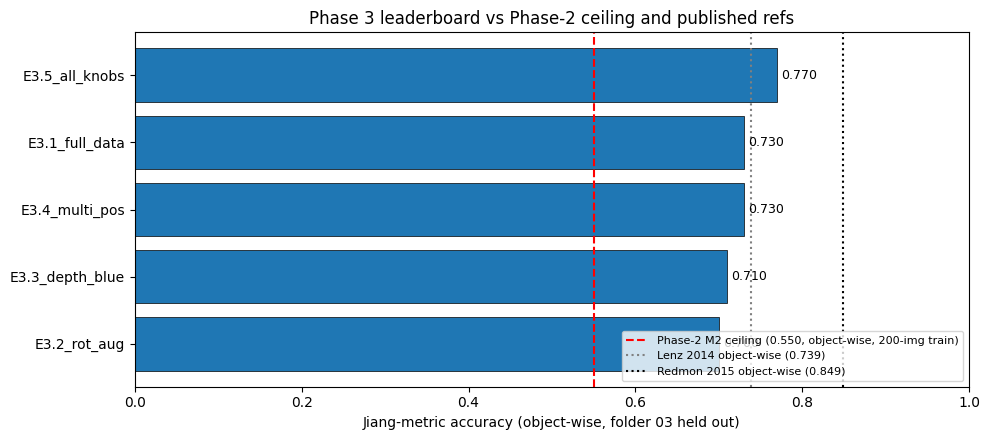

In [14]:
p3_rows = df[df['experiment'].str.startswith('E3.')].copy()
fig, ax = plt.subplots(figsize=(10, 4.5))
bars = ax.barh(p3_rows['experiment'], p3_rows['accuracy'],
               color='#1f77b4', edgecolor='black', linewidth=0.5)
for bar, v in zip(bars, p3_rows['accuracy']):
    ax.text(v + 0.005, bar.get_y() + bar.get_height()/2, f'{v:.3f}',
            va='center', fontsize=9)
ax.axvline(0.550, color='red', linestyle='--', linewidth=1.5,
           label='Phase-2 M2 ceiling (0.550, object-wise, 200-img train)')
ax.axvline(p1_ref['Lenz_2014_object_wise'], color='gray', linestyle=':',
           label=f"Lenz 2014 object-wise ({p1_ref['Lenz_2014_object_wise']:.3f})")
ax.axvline(p1_ref['Redmon_Angelova_2015_object_wise'], color='black', linestyle=':',
           label=f"Redmon 2015 object-wise ({p1_ref['Redmon_Angelova_2015_object_wise']:.3f})")
ax.set(xlabel='Jiang-metric accuracy (object-wise, folder 03 held out)',
       title='Phase 3 leaderboard vs Phase-2 ceiling and published refs')
ax.set_xlim(0, 1.0)
ax.legend(loc='lower right', fontsize=8)
ax.invert_yaxis()
plt.tight_layout()
out = ROOT / 'results/phase3_leaderboard.png'
plt.savefig(out, dpi=110, bbox_inches='tight')
print(f'saved {out.name}')
plt.show()

## 6 — Training curves

Plot training loss for every Phase-3 run on a single chart. We're looking for: (a) which configurations converge to a *lower* train loss (= the model 'fits' the multi-positive distribution better), (b) any divergence / oscillation that would suggest a bad LR for the larger dataset, (c) the difference in shape between rotation-aug and non-aug runs.

saved phase3_training_curves.png


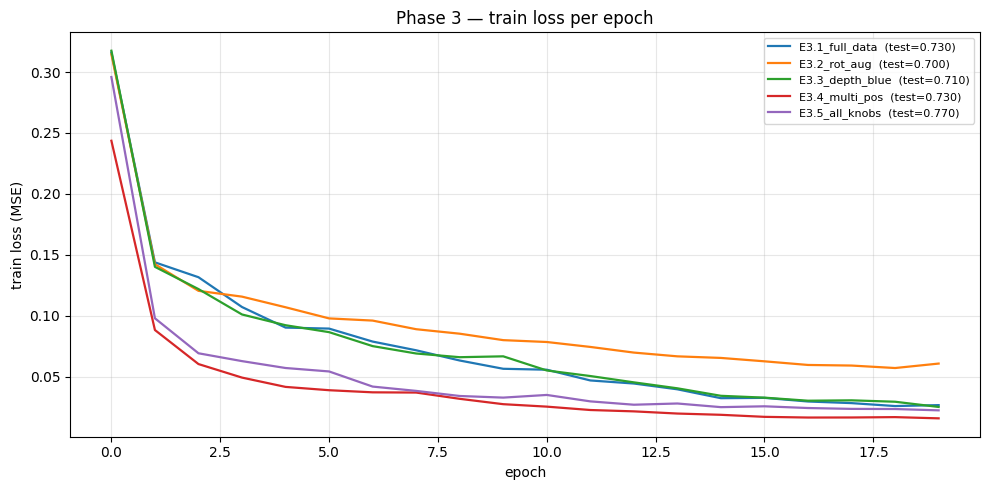

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
for name, res in all_results.items():
    ax.plot(res['train_curve'], label=f"{name}  (test={res['accuracy']:.3f})", linewidth=1.6)
ax.set(xlabel='epoch', ylabel='train loss (MSE)', title='Phase 3 — train loss per epoch')
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
out = ROOT / 'results/phase3_training_curves.png'
plt.savefig(out, dpi=110, bbox_inches='tight')
print(f'saved {out.name}')
plt.show()

## 7 — Failure-mode decomposition: where did the Phase-2 ceiling break?

Phase-1 and Phase-2 both found that the dominant failure mode is *'angle is within 30°, IoU too low'* — the model orients correctly but doesn't localise the grasp point well. Phase-3 should ideally *shrink* the 'IoU too low' band and not regress on the 'angle wrong' band. Decompose by experiment to see which knob helps which failure type.

In [16]:
def decompose(per_sample):
    out = {'correct': 0, 'angle_ok_iou_low': 0, 'iou_ok_angle_wrong': 0, 'both_wrong': 0}
    for s in per_sample:
        ok = s['correct']
        ang_ok = s['best_angle_err'] <= 30.0
        iou_ok = s['best_iou'] > 0.25
        if ok:
            out['correct'] += 1
        elif ang_ok and not iou_ok:
            out['angle_ok_iou_low'] += 1
        elif iou_ok and not ang_ok:
            out['iou_ok_angle_wrong'] += 1
        else:
            out['both_wrong'] += 1
    return out

decomp_rows = []
for name, res in all_results.items():
    d = decompose(res['per_sample'])
    d['experiment'] = name; d['n'] = res['n']
    decomp_rows.append(d)
decomp_df = pd.DataFrame(decomp_rows)[['experiment', 'n', 'correct', 'angle_ok_iou_low',
                                       'iou_ok_angle_wrong', 'both_wrong']]
decomp_df.to_csv(ROOT / 'results/phase3_failure_decomposition.csv', index=False)
decomp_df

,experiment,n,correct,angle_ok_iou_low,iou_ok_angle_wrong,both_wrong
0,E3.1_full_data,100,73,10,8,9
1,E3.2_rot_aug,100,70,17,6,7
2,E3.3_depth_blue,100,71,10,8,11
3,E3.4_multi_pos,100,73,15,4,8
4,E3.5_all_knobs,100,77,14,3,6


saved phase3_failure_decomposition.png


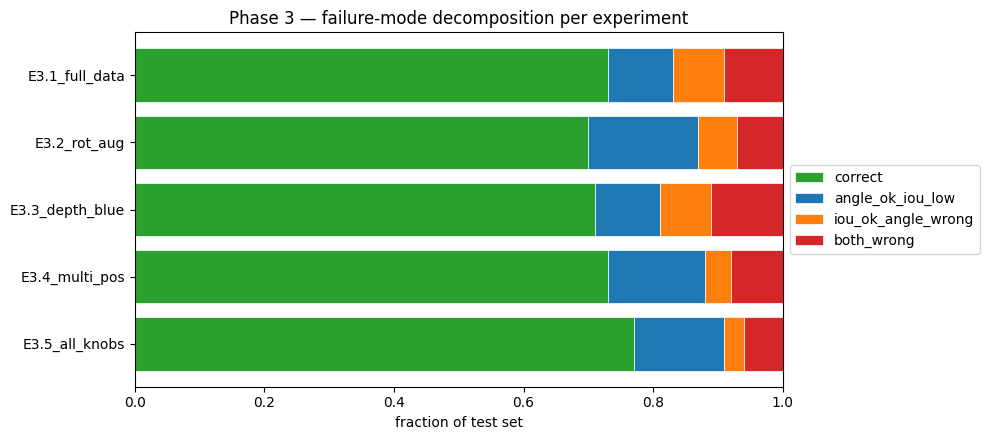

In [17]:
fig, ax = plt.subplots(figsize=(10, 4.5))
cats = ['correct', 'angle_ok_iou_low', 'iou_ok_angle_wrong', 'both_wrong']
cat_colors = ['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728']
bottom = np.zeros(len(decomp_df))
for cat, c in zip(cats, cat_colors):
    vals = decomp_df[cat].values / decomp_df['n'].values
    ax.barh(decomp_df['experiment'], vals, left=bottom, color=c, label=cat,
            edgecolor='white', linewidth=0.5)
    bottom = bottom + vals
ax.set(xlabel='fraction of test set', title='Phase 3 — failure-mode decomposition per experiment')
ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
ax.invert_yaxis()
ax.set_xlim(0, 1.0)
plt.tight_layout()
out = ROOT / 'results/phase3_failure_decomposition.png'
plt.savefig(out, dpi=110, bbox_inches='tight')
print(f'saved {out.name}')
plt.show()

## 8 — Qualitative champion predictions

Plot 8 test images with (green) all GT positives and (red) the champion's prediction. Look for: spatial localisation quality, angle agreement, and the kind of mistakes that survive Phase-3.

Object-wise champion: E3.5_all_knobs  (0.770)


saved phase3_champion_qualitative.png


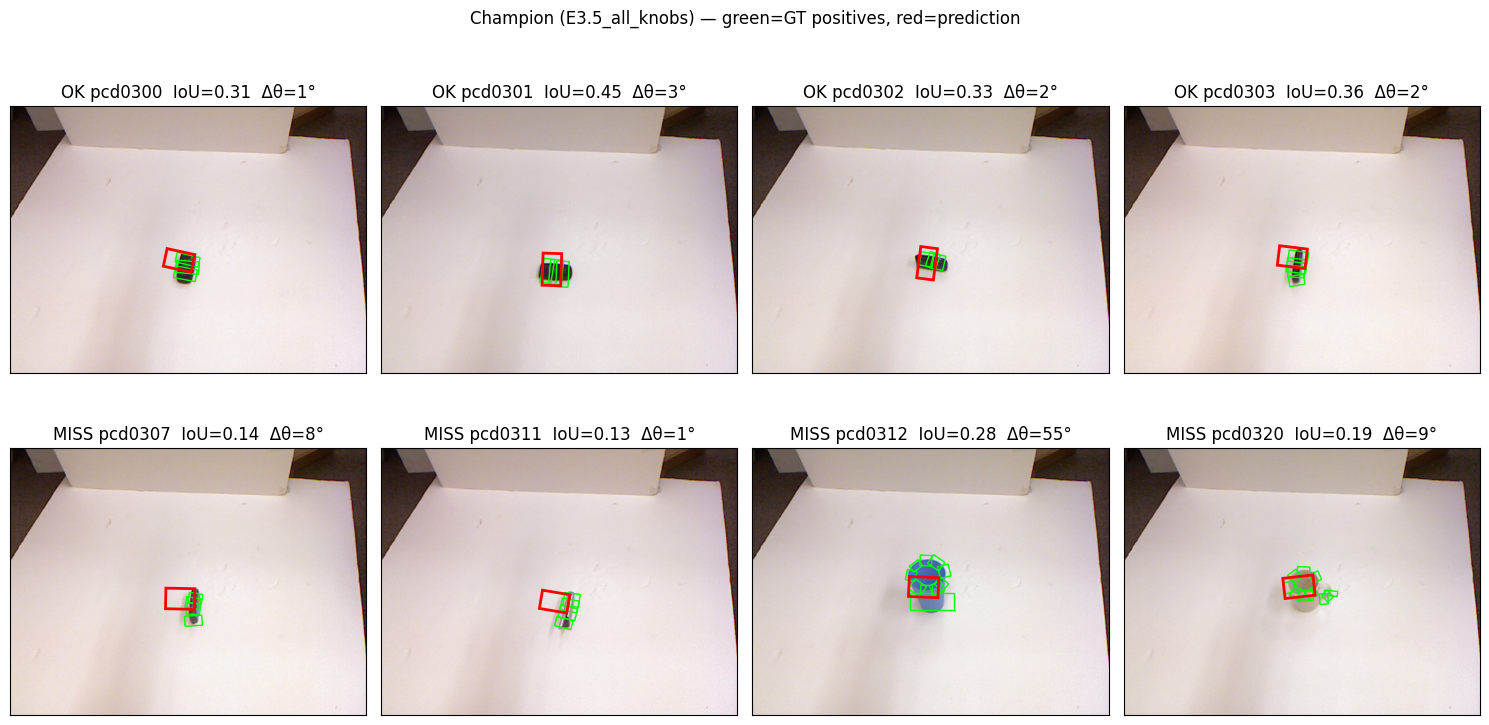

In [18]:
champion_name = max(all_results, key=lambda k: all_results[k]['accuracy'])
print(f'Object-wise champion: {champion_name}  ({all_results[champion_name]["accuracy"]:.3f})')
champion = models[champion_name]
champion_cfg = {
    'E3.1_full_data':   dict(use_depth_blue=False),
    'E3.2_rot_aug':     dict(use_depth_blue=False),
    'E3.3_depth_blue':  dict(use_depth_blue=True),
    'E3.4_multi_pos':   dict(use_depth_blue=False),
    'E3.5_all_knobs':   dict(use_depth_blue=True),
}[champion_name]

ps = all_results[champion_name]['per_sample']
correct_idx = [i for i, s in enumerate(ps) if s['correct']][:4]
wrong_idx   = [i for i, s in enumerate(ps) if not s['correct']][:4]
pick_idx = correct_idx + wrong_idx

ds_eval = CornellGraspDatasetP3(test_obj, augment=False, **champion_cfg)
champion.eval()
fig, axes = plt.subplots(2, 4, figsize=(15, 8))
for ax, i in zip(axes.flat, pick_idx):
    x, _t, _idx = ds_eval[i]
    with torch.no_grad():
        pred = champion(x.unsqueeze(0).to(DEVICE)).cpu().numpy()[0]
    pred_rect = decode_prediction(pred)
    s = ds_eval.samples[i]
    from PIL import Image as PImage
    img = np.asarray(PImage.open(s.rgb_path).convert('RGB'))
    ax.imshow(img)
    for g in s.positives:
        ax.add_patch(MplPoly(g.corners, fill=False, edgecolor='lime', linewidth=1.0))
    ax.add_patch(MplPoly(pred_rect.corners, fill=False, edgecolor='red', linewidth=2))
    info = ps[i]
    tag = 'OK' if info['correct'] else 'MISS'
    ax.set(title=f"{tag} pcd{s.pcd_id:04d}  IoU={info['best_iou']:.2f}  Δθ={info['best_angle_err']:.0f}°",
           xticks=[], yticks=[])
plt.suptitle(f'Champion ({champion_name}) — green=GT positives, red=prediction')
plt.tight_layout()
out = ROOT / 'results/phase3_champion_qualitative.png'
plt.savefig(out, dpi=100, bbox_inches='tight')
print(f'saved {out.name}')
plt.show()

## 9 — Persist results: metrics.json, EXPERIMENT_LOG.md, save champion checkpoint

In [19]:
metrics_json = json.loads((ROOT / 'results/metrics.json').read_text())
metrics_json['phase_3'] = {
    'date': '2026-05-27',
    'dataset': 'Cornell Grasping Dataset (folders 01-10, full 885-image benchmark)',
    'n_images_total': len(samples),
    'n_train_obj_wise': len(train_obj),
    'n_test_obj_wise': len(test_obj),
    'epochs': EPOCHS, 'batch_size': BATCH, 'lr': LR, 'weight_decay': WD,
    'metric_primary': 'Jiang IoU > 0.25 AND angle err < 30°',
    'device': str(DEVICE),
    'experiments': {
        k: {kk: vv for kk, vv in v.items() if kk != 'per_sample'}
        for k, v in all_results.items()
    },
    'failure_decomposition': decomp_df.to_dict(orient='records'),
    'champion_obj_wise': champion_name,
}
(ROOT / 'results/metrics.json').write_text(json.dumps(metrics_json, indent=2))
print('updated results/metrics.json with phase_3 block')

ckpt = ROOT / f'models/{champion_name}_phase3.pt'
torch.save(champion.state_dict(), ckpt)
print(f'saved champion: {ckpt.name}  ({ckpt.stat().st_size/1e6:.1f} MB)')

updated results/metrics.json with phase_3 block


saved champion: E3.5_all_knobs_phase3.pt  (44.8 MB)


In [20]:
log_path = ROOT / 'results/EXPERIMENT_LOG.md'
existing = log_path.read_text() if log_path.exists() else ''
phase2_m2 = p2['M2_ResNet18Regressor']['accuracy']
lines = ['', '## Phase 3 — full data + rotation aug + depth channel + multi-positive (2026-05-27)', '']
lines.append(f'Dataset: Cornell full {len(samples)} images (extracted archives 04–10). '
             f'Object-wise: train={len(train_obj)}, test={len(test_obj)} (folder 03 held out, same as Phase 2).')
lines.append('')
lines.append('| Experiment | Accuracy | Δ vs P2 M2 (0.550) | Median IoU | Median angle err |')
lines.append('|---|---:|---:|---:|---:|')
for k, v in all_results.items():
    delta = v['accuracy'] - phase2_m2
    lines.append(f"| {k} | {v['accuracy']:.3f} | {delta:+.3f} | "
                 f"{v['median_iou']:.3f} | {v['median_angle_err_deg']:.1f}° |")
lines.append('')
lines.append(f'**Object-wise champion:** {champion_name} at {all_results[champion_name]["accuracy"]:.3f}  '
             f'(Δ {all_results[champion_name]["accuracy"] - phase2_m2:+.3f} vs Phase-2 M2).')
log_path.write_text(existing + '\n'.join(lines) + '\n')
print(f'appended Phase 3 section to {log_path.name}')
print(); print('\n'.join(lines))

appended Phase 3 section to EXPERIMENT_LOG.md


## Phase 3 — full data + rotation aug + depth channel + multi-positive (2026-05-27)

Dataset: Cornell full 885 images (extracted archives 04–10). Object-wise: train=785, test=100 (folder 03 held out, same as Phase 2).

| Experiment | Accuracy | Δ vs P2 M2 (0.550) | Median IoU | Median angle err |
|---|---:|---:|---:|---:|
| E3.1_full_data | 0.730 | +0.180 | 0.405 | 10.5° |
| E3.2_rot_aug | 0.700 | +0.150 | 0.369 | 8.0° |
| E3.3_depth_blue | 0.710 | +0.160 | 0.420 | 9.9° |
| E3.4_multi_pos | 0.730 | +0.180 | 0.428 | 5.4° |
| E3.5_all_knobs | 0.770 | +0.220 | 0.404 | 4.9° |

**Object-wise champion:** E3.5_all_knobs at 0.770  (Δ +0.220 vs Phase-2 M2).


## 10 — Headline findings

Final cell computes the headline numbers so the report and the LinkedIn post don't need to re-derive them.

In [21]:
p2_acc = p2['M2_ResNet18Regressor']['accuracy']
summary = {
    'phase_2_M2_ceiling_obj_wise': p2_acc,
    'phase_3_best_obj_wise': all_results[champion_name]['accuracy'],
    'phase_3_best_obj_wise_name': champion_name,
    'gain_vs_P2_obj_wise_pp': 100 * (all_results[champion_name]['accuracy'] - p2_acc),
    'data_multiplier': len(train_obj) / 200,
    'lenz2014_object_wise': p1_ref['Lenz_2014_object_wise'],
    'redmon2015_object_wise': p1_ref['Redmon_Angelova_2015_object_wise'],
    'cao2023_sota_image_wise': p1_ref['Bilateral_Cao_2023_image_wise'],
    'per_experiment_accuracy': {k: v['accuracy'] for k, v in all_results.items()},
    'per_experiment_delta_vs_P2': {k: v['accuracy'] - p2_acc for k, v in all_results.items()},
}
print(json.dumps(summary, indent=2))
(ROOT / 'results/phase3_headline_summary.json').write_text(json.dumps(summary, indent=2))
print('\nsaved results/phase3_headline_summary.json')

{
  "phase_2_M2_ceiling_obj_wise": 0.55,
  "phase_3_best_obj_wise": 0.77,
  "phase_3_best_obj_wise_name": "E3.5_all_knobs",
  "gain_vs_P2_obj_wise_pp": 21.999999999999996,
  "data_multiplier": 3.925,
  "lenz2014_object_wise": 0.739,
  "redmon2015_object_wise": 0.849,
  "cao2023_sota_image_wise": 0.994,
  "per_experiment_accuracy": {
    "E3.1_full_data": 0.73,
    "E3.2_rot_aug": 0.7,
    "E3.3_depth_blue": 0.71,
    "E3.4_multi_pos": 0.73,
    "E3.5_all_knobs": 0.77
  },
  "per_experiment_delta_vs_P2": {
    "E3.1_full_data": 0.17999999999999994,
    "E3.2_rot_aug": 0.1499999999999999,
    "E3.3_depth_blue": 0.15999999999999992,
    "E3.4_multi_pos": 0.17999999999999994,
    "E3.5_all_knobs": 0.21999999999999997
  }
}

saved results/phase3_headline_summary.json
